# House Price Prediction System

## AIML Summer Internship Project

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [2]:
df = pd.read_csv("../Dataset/House_Price_India.csv")

In [3]:
df.head()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
1,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
2,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
3,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000
4,6762813105,42491,3,2.50,2600,4750,1.0,0,0,4,...,1951,0,122007,52.9133,-114.590,2380,4750,1,67,790000


In [4]:
df.shape

(14619, 23)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14619 entries, 0 to 14618
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14619 non-null  int64  
 1   Date                                   14619 non-null  int64  
 2   number of bedrooms                     14619 non-null  int64  
 3   number of bathrooms                    14619 non-null  float64
 4   living area                            14619 non-null  int64  
 5   lot area                               14619 non-null  int64  
 6   number of floors                       14619 non-null  float64
 7   waterfront present                     14619 non-null  int64  
 8   number of views                        14619 non-null  int64  
 9   condition of the house                 14619 non-null  int64  
 10  grade of the house                     14619 non-null  int64  
 11  Area of the h

In [6]:
df.describe()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
count,1.461900e+04,14619.000000,14619.000000,14619.000000,14619.000000,1.461900e+04,14619.000000,14619.000000,14619.000000,14619.000000,...,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,14619.000000,1.461900e+04
mean,6.762821e+09,42604.546412,3.379233,2.129557,2098.156851,1.509369e+04,1.502326,0.007661,0.232848,3.430399,...,1970.929817,90.930228,122033.064300,52.792843,-114.403996,1996.641836,12754.003078,2.012244,64.951433,5.388063e+05
std,6.237162e+03,67.343747,0.938655,0.769955,928.218740,3.792089e+04,0.540241,0.087196,0.765651,0.664047,...,29.491743,416.230218,19.081451,0.137525,0.141325,691.078387,26059.234785,0.817312,8.936129,3.672294e+05
min,6.762810e+09,42491.000000,1.000000,0.500000,370.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,...,1900.000000,0.000000,122003.000000,52.385900,-114.709000,460.000000,651.000000,1.000000,50.000000,7.800000e+04
25%,6.762815e+09,42546.000000,3.000000,1.750000,1440.000000,5.010500e+03,1.000000,0.000000,0.000000,3.000000,...,1951.000000,0.000000,122017.000000,52.707600,-114.519000,1490.000000,5097.500000,1.000000,57.000000,3.200000e+05
50%,6.762821e+09,42600.000000,3.000000,2.250000,1930.000000,7.620000e+03,1.500000,0.000000,0.000000,3.000000,...,1975.000000,0.000000,122032.000000,52.806400,-114.421000,1850.000000,7620.000000,2.000000,65.000000,4.500000e+05
75%,6.762826e+09,42662.000000,4.000000,2.500000,2570.000000,1.080000e+04,2.000000,0.000000,0.000000,4.000000,...,1997.000000,0.000000,122048.000000,52.908900,-114.315000,2380.000000,10125.000000,3.000000,73.000000,6.450000e+05
max,6.762832e+09,42734.000000,33.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,...,2015.000000,2015.000000,122072.000000,53.007600,-113.505000,6110.000000,560617.000000,3.000000,80.000000,7.700000e+06


In [7]:
df.isnull().sum()

id                                       0
Date                                     0
number of bedrooms                       0
number of bathrooms                      0
living area                              0
lot area                                 0
number of floors                         0
waterfront present                       0
number of views                          0
condition of the house                   0
grade of the house                       0
Area of the house(excluding basement)    0
Area of the basement                     0
Built Year                               0
Renovation Year                          0
Postal Code                              0
Lattitude                                0
Longitude                                0
living_area_renov                        0
lot_area_renov                           0
Number of schools nearby                 0
Distance from the airport                0
Price                                    0
dtype: int6

In [8]:
df.drop(
    columns=[
        "id",
        "Date",
        "Postal Code",
        "Lattitude",
        "Longitude",
        "waterfront present",
        "number of views",
        "Renovation Year",
        "living_area_renov",
        "lot_area_renov"
    ],
    inplace=True
)

In [9]:
df.columns

Index(['number of bedrooms', 'number of bathrooms', 'living area', 'lot area',
       'number of floors', 'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Number of schools nearby', 'Distance from the airport',
       'Price'],
      dtype='str')

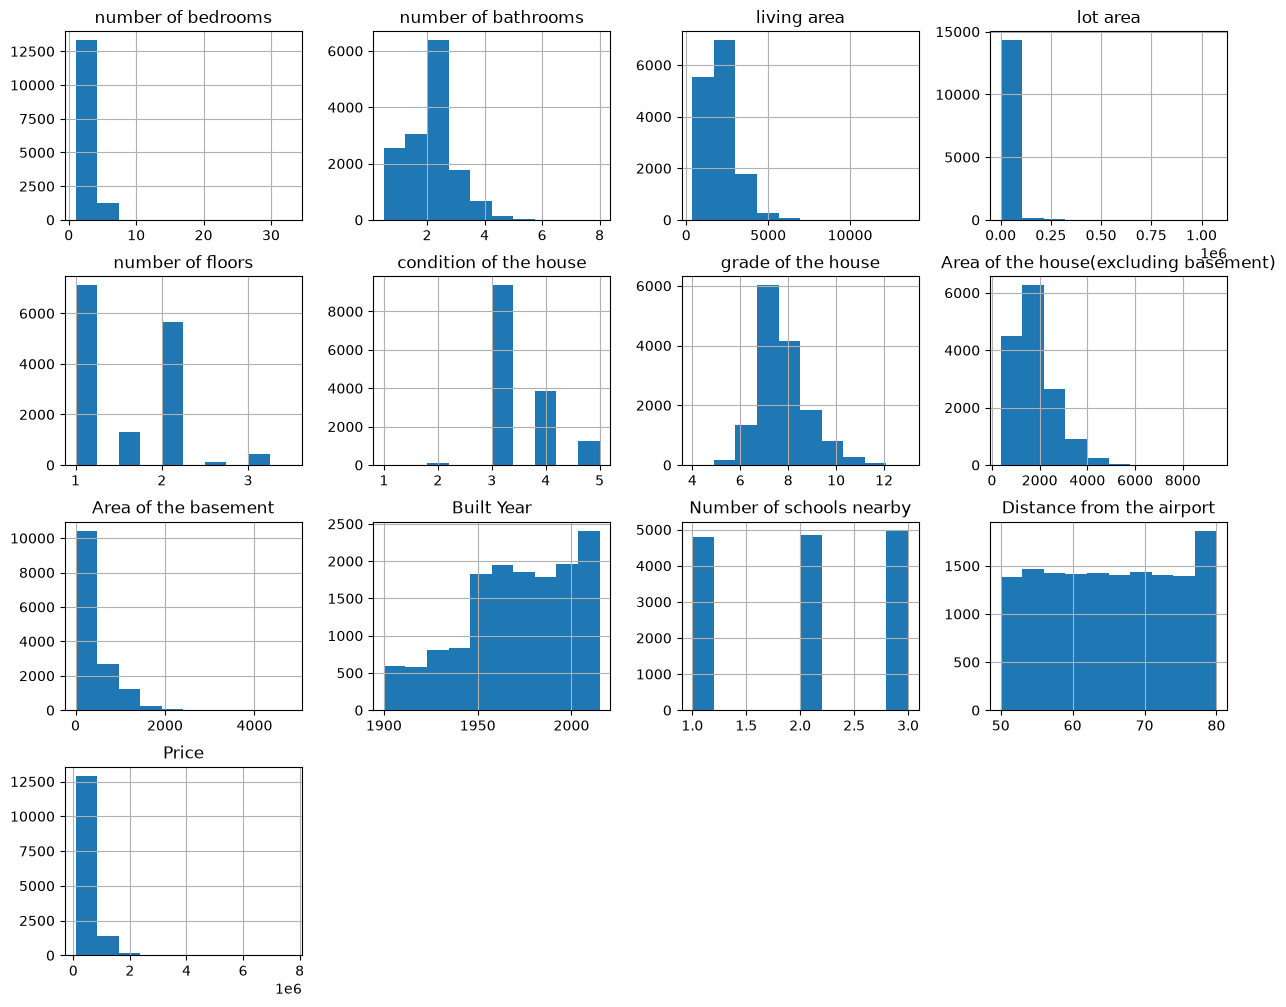

In [10]:
df.hist(figsize=(15,12))
plt.show()

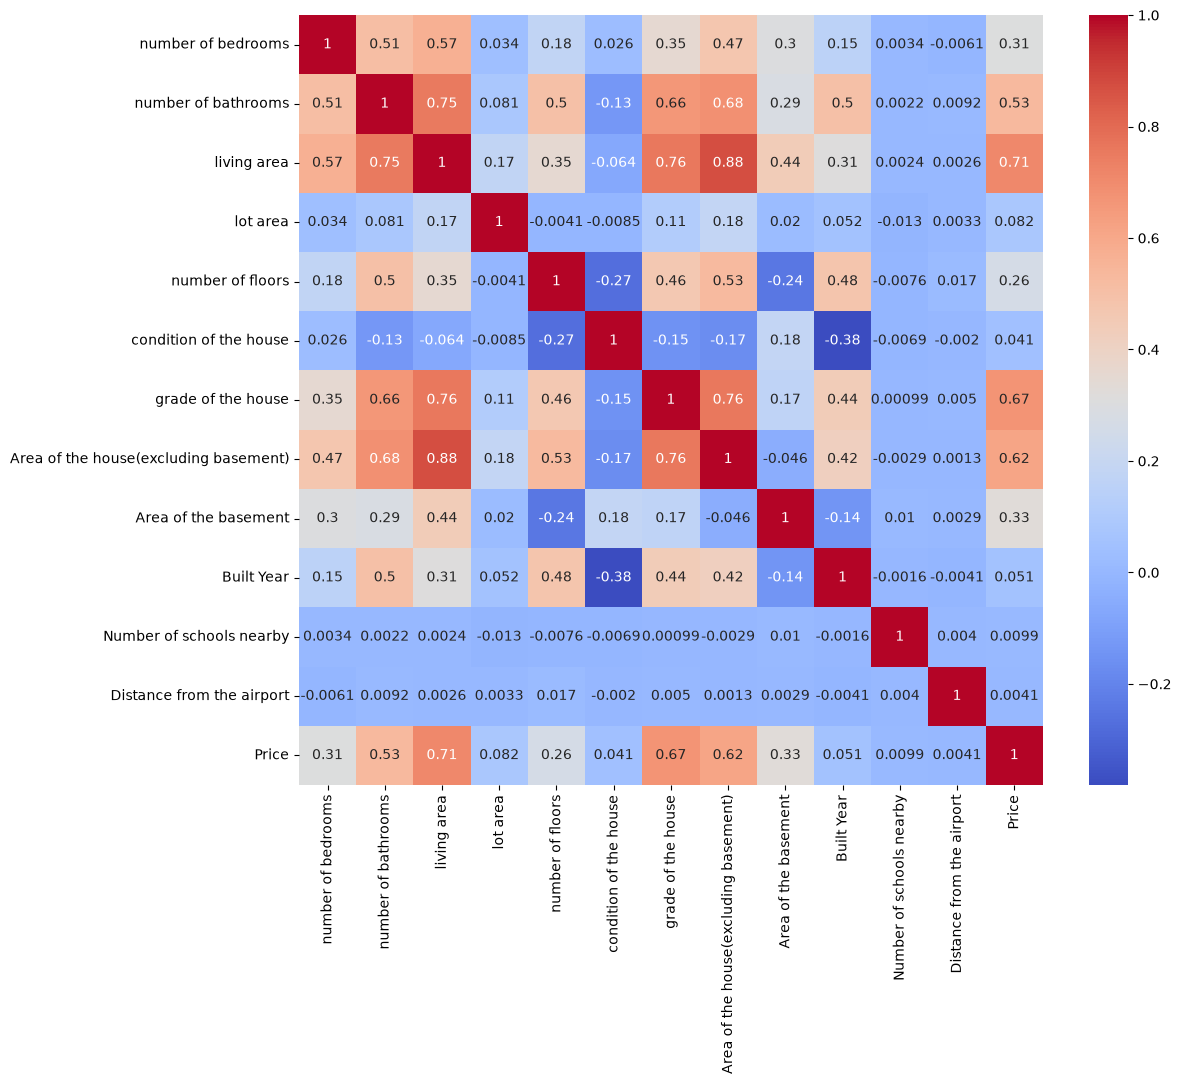

In [11]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

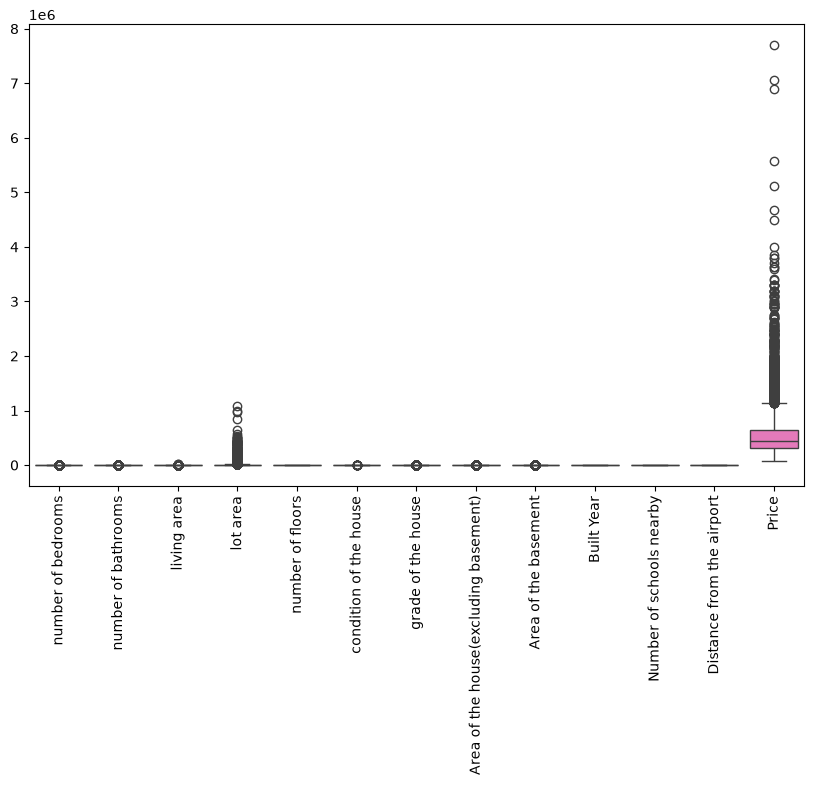

In [12]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [13]:
X = df.drop("Price",axis=1)

y = df["Price"]

In [14]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
lr=LinearRegression()

lr.fit(X_train,y_train)

lr_pred=lr.predict(X_test)

In [16]:
rf=RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred=rf.predict(X_test)

In [17]:
xgb=XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train,y_train)

xgb_pred=xgb.predict(X_test)

In [18]:
def evaluate(y_true,y_pred,name):

    print(name)

    print("MAE :",mean_absolute_error(y_true,y_pred))

    print("RMSE :",np.sqrt(mean_squared_error(y_true,y_pred)))

    print("R2 :",r2_score(y_true,y_pred))

    print()

In [19]:
evaluate(y_test,lr_pred,"Linear Regression")

evaluate(y_test,rf_pred,"Random Forest")

evaluate(y_test,xgb_pred,"XGBoost")

Linear Regression
MAE : 143805.53477963788
RMSE : 232215.15822122642
R2 : 0.6356397901087767

Random Forest
MAE : 127027.56282066317
RMSE : 212284.7002939888
R2 : 0.6955000663553434

XGBoost
MAE : 126026.765625
RMSE : 210110.41120325285
R2 : 0.7017056941986084



In [20]:
%whos

Variable                Type                     Data/Info
----------------------------------------------------------
LinearRegression        ABCMeta                  <class 'sklearn.linear_mo<...>._base.LinearRegression'>
RandomForestRegressor   ABCMeta                  <class 'sklearn.ensemble.<...>t.RandomForestRegressor'>
X                       DataFrame                Shape: (14619, 12)
XGBRegressor            type                     <class 'xgboost.sklearn.XGBRegressor'>
X_test                  DataFrame                Shape: (2924, 12)
X_train                 DataFrame                Shape: (11695, 12)
df                      DataFrame                Shape: (14619, 13)
evaluate                function                 <function evaluate at 0x000001713D3D2840>
joblib                  module                   <module 'joblib' from 'c:<...>es\\joblib\\__init__.py'>
lr                      LinearRegression         LinearRegression()
lr_pred                 ndarray                  

In [21]:
import joblib

joblib.dump(xgb, "../Model/house_price_model.pkl")

['../Model/house_price_model.pkl']

In [22]:
from pathlib import Path

Path("../Model/house_price_model.pkl").exists()

True

In [23]:
X.columns.tolist()


['number of bedrooms',
 'number of bathrooms',
 'living area',
 'lot area',
 'number of floors',
 'condition of the house',
 'grade of the house',
 'Area of the house(excluding basement)',
 'Area of the basement',
 'Built Year',
 'Number of schools nearby',
 'Distance from the airport']

In [24]:
print(X.columns.tolist())

['number of bedrooms', 'number of bathrooms', 'living area', 'lot area', 'number of floors', 'condition of the house', 'grade of the house', 'Area of the house(excluding basement)', 'Area of the basement', 'Built Year', 'Number of schools nearby', 'Distance from the airport']


In [25]:
import joblib

joblib.dump(xgb, "../Model/house_price_model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [26]:
print(df["Price"].describe())

count    1.461900e+04
mean     5.388063e+05
std      3.672294e+05
min      7.800000e+04
25%      3.200000e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: Price, dtype: float64


In [27]:
print(df["Price"].min())
print(df["Price"].max())

78000
7700000


In [28]:
sample = X.iloc[[0]]

print("Actual Price:", y.iloc[0])
print("Predicted Price:", xgb.predict(sample)[0])

Actual Price: 1400000
Predicted Price: 1.1167078e+06


In [29]:
pred = xgb.predict(X)

print("Minimum prediction:", pred.min())
print("Maximum prediction:", pred.max())

Minimum prediction: 143871.3
Maximum prediction: 7.6782345e+06


In [30]:
print(X.columns.tolist())

['number of bedrooms', 'number of bathrooms', 'living area', 'lot area', 'number of floors', 'condition of the house', 'grade of the house', 'Area of the house(excluding basement)', 'Area of the basement', 'Built Year', 'Number of schools nearby', 'Distance from the airport']


In [31]:
print(X.columns.tolist())

['number of bedrooms', 'number of bathrooms', 'living area', 'lot area', 'number of floors', 'condition of the house', 'grade of the house', 'Area of the house(excluding basement)', 'Area of the basement', 'Built Year', 'Number of schools nearby', 'Distance from the airport']


In [32]:
sample = np.array([[3,2,2000,5000,1,3,6,1800,200,2000,5,10]])

print(xgb.predict(sample))

[345557.2]


In [33]:
print(X.iloc[0])
print(y.iloc[0])

number of bedrooms                          4.0
number of bathrooms                         2.5
living area                              2920.0
lot area                                 4000.0
number of floors                            1.5
condition of the house                      5.0
grade of the house                          8.0
Area of the house(excluding basement)    1910.0
Area of the basement                     1010.0
Built Year                               1909.0
Number of schools nearby                    2.0
Distance from the airport                  51.0
Name: 0, dtype: float64
1400000
